# **Машинное обучение 1, ПМИ ФКН ВШЭ. Бонусное домашнее задание**
##  **Основные методы оценки важности признаков для ML моделей**

В этом домашнем задании вы будете работать с данными о Всемирном отчёте о счастье (World Happiness Report). В качестве теории используйте следующие семинарские материалы: 
- [Основные методы оценки важности признаков для ML моделей](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.ipynb);
- [Интерпретация по определению](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.pdf).

**Общая информация**

**Дата выдачи:** 04.05.2026

**Дедлайн:** 18.05.2026 23:59MSK

**Оценивание и штрафы**

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу - 5 баллов.

Как всегда, сдача после жёсткого дедлайна невозможна. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).


**NB** В этом задании много работ, требующих вывода и размышлений. Куцые выводы, как и неэффективная реализация кода, могут негативно отразиться на оценке.



**Задания сдаются через систему anytask.** Посылка должна содержать:

Ноутбук homework-practice-xai-Username.ipynb
Username - ваша фамилия и имя на латинице именно в таком порядке.


## **Подготовительная часть**

In [1]:
!pip3 install shap -qU


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip3 install -qU pyALE


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip3 install -qU lime "fat-forensics[all]"


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### **Подготовка данных**

Загрузите датасет по ссылке.

In [4]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [5]:
!wget  -O 'data/world-happiness-report-2021-prep.csv' -q 'https://www.dropbox.com/scl/fi/vn5d4awcg7n307bnewr2x/world-happiness-report-2021-prep-1.csv?rlkey=yk8sn3fblpvtu8iyc02vpryhp&st=cvysdgto&dl=0'

In [6]:
data_to_work = pl.read_csv("data/world-happiness-report-2021-prep.csv")

data_to_work.head(5)

Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
f64,f64,f64,f64,f64,f64,f64,f64
7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
7.62,10.933,0.954,72.7,0.946,0.03,0.179,2.868
7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
7.554,10.878,0.983,73.0,0.955,0.16,0.673,2.967
7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


### Примечание про столбец Dystopia + residual.


В World Happiness Report Dystopia - это не реальная страна, а техническая точка отсчёта: гипотетическая страна с минимальными значениями по ключевым факторам (GDP, social support, life expectancy, freedom, generosity, corruption). Её вводят как бенчмарк, чтобы вклады факторов в разложении были неотрицательными.

Столбец `Dystopia + residual` - это  разложения: базовый уровень (оценка жизни в Dystopia) плюс остаточная часть, которую шесть факторов не объясняют для конкретной страны (ошибка/невязка модели). Это не социальный индекс, а слагаемое, которое вместе с вкладами 6 факторов даёт итоговый score.

Иначе говоря, в таблицах WHR:
Score ~ (вклады 6 факторов) + (Dystopia + residual).

### Поехали дальше

In [7]:
X = data_to_work.drop("Ladder score")
y = data_to_work["Ladder score"]

Для обучения будем использовать два способа масштабирования - `MinMaxScaler` и `StandardScaler`.

In [8]:
feature_names = list(X.columns)

# Выберем признак для анализа
feature_idx = 1
feature_name = X.columns[feature_idx]

print(f"FEATURE TO ANALYZE: {feature_name}")

FEATURE TO ANALYZE: Social support


In [9]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 1
sc_minmax = MinMaxScaler()
X_train_sc_minmax = sc_minmax.fit_transform(X_train)
X_test_sc_minmax = sc_minmax.transform(X_test)

# 2
sc_standard = StandardScaler()
X_train_sc_standard = sc_standard.fit_transform(X_train)
X_test_sc_standard = sc_standard.transform(X_test)

### **Задание 1. (0.5 балла)**
- Обучите 6 моделей:
  -  линейную регрессию (`LinearRegression`) на двух вариантах данных;
  - Lasso регрессию (`Lasso`) на двух вариантах данных;
  - градиентный бустинг (`GradientBoostingRegressor`) на двух вариантах данных;
- Выведите MSE и RMSE моделей.
- Зафиксируйте выводы.

> Цель задания - увидеть, какие модели чувствительны к масштабу признаков (Lasso), а какие почти инвариантны (LR/деревья), и почему это важно для интерпретации.


**NB:** Для бустингов ограничьте глубину до 5.

In [10]:
error_df = pl.DataFrame(
    {
        "model": ["foo"],
        "scaler": ["foo"],
        "mse": [0.0],
        "rmse": [0.0],
    }
).clear()

models_save = {}

for xtr, xts, tp in [
    (X_train_sc_minmax, X_test_sc_minmax, "min_max"),
    (X_train_sc_standard, X_test_sc_standard, "std"),
]:
    models = [
        (LinearRegression(), "linear"),
        (Lasso(alpha=0.1), "lasso"),
        (GradientBoostingRegressor(), "GBR"),
    ]
    for model, model_name in models:
        model.fit(xtr, y_train)
        y_pred = model.predict(xts)

        models_save[(model_name, tp)] = model

        error_df = error_df.vstack(
            pl.DataFrame(
                {
                    "model": model_name,
                    "scaler": tp,
                    "mse": mean_squared_error(y_pred=y_pred, y_true=y_test),
                    "rmse": root_mean_squared_error(y_pred=y_pred, y_true=y_test),
                }
            )
        )
error_df.sort(by="model")

model,scaler,mse,rmse
str,str,f64,f64
"""GBR""","""min_max""",0.051738,0.227461
"""GBR""","""std""",0.051156,0.226176
"""lasso""","""min_max""",0.488754,0.69911
"""lasso""","""std""",0.029812,0.172662
"""linear""","""min_max""",9.8419e-7,0.000992
"""linear""","""std""",9.8419e-7,0.000992


## **1. Интерпретация по определению**

Воспользуемся встроенными важностями в моделях. Для бустинга — усредненная важность по деревьям, для регрессий — коэффициенты.

### **Задание 2. (0.25 балла)**
- Постройте график (любой, на ваш выбор), позволяющий визуально оценить и сравнить коэффициенты по парам моделей:
  - Модель и `StandardScaler` vs Модель и `MinMaxScaler`
- Зафиксируйте выводы по каждой из пар графиков.

linear
lasso
GBR


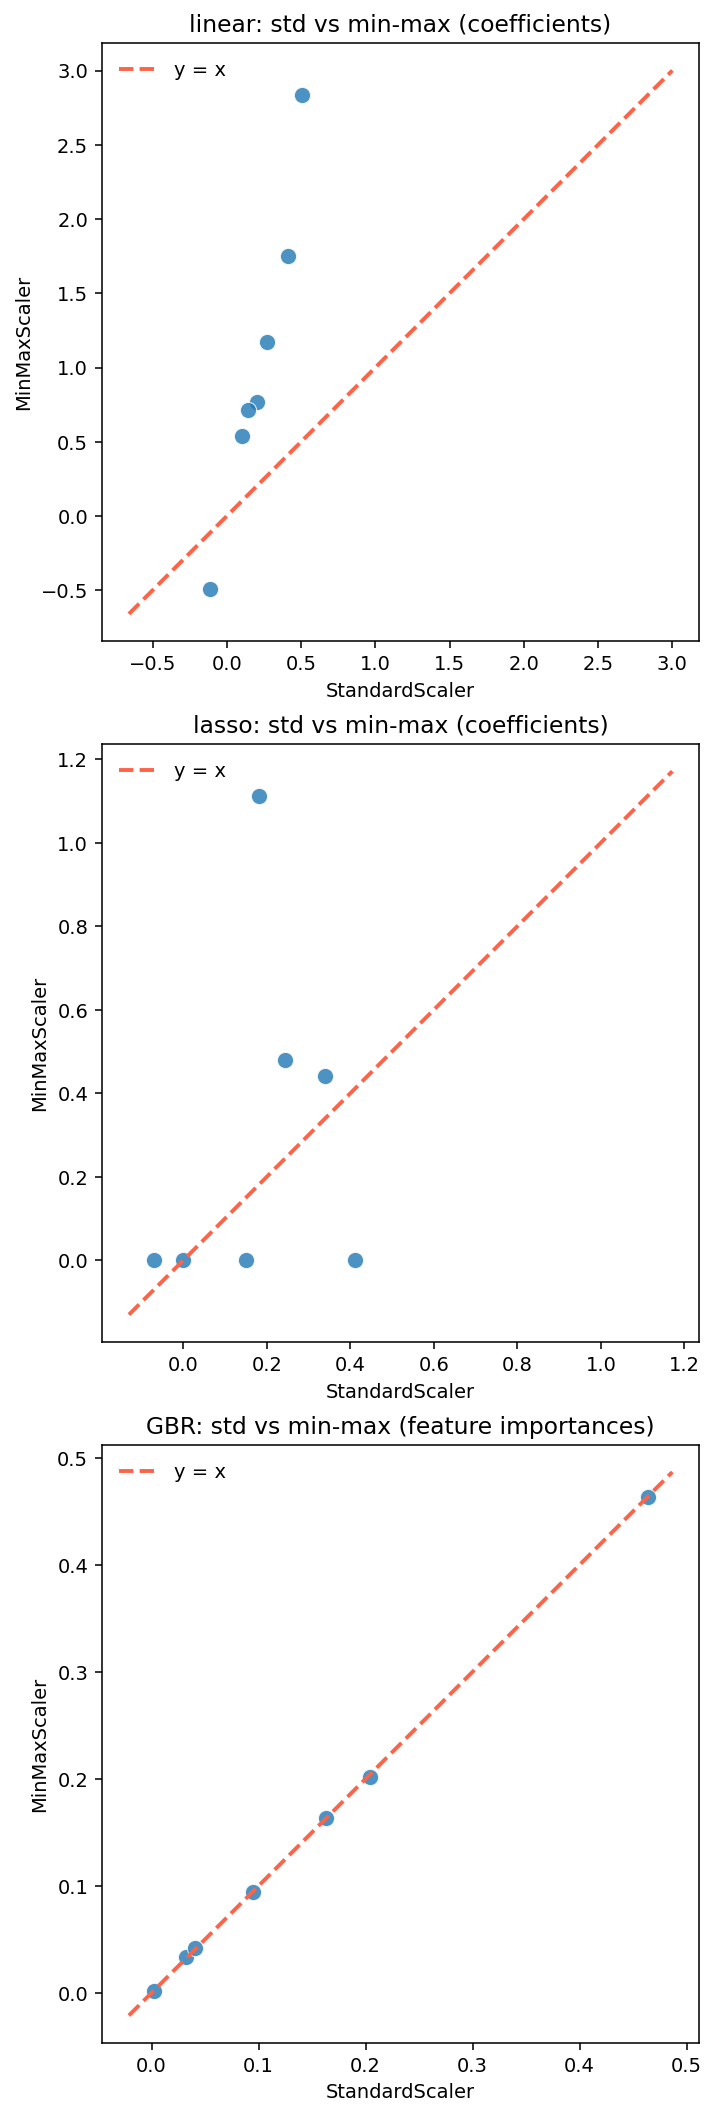

In [11]:
import seaborn as sns

model_names = error_df.select("model").unique()["model"]

n = len(model_names)
fig, axes = plt.subplots(
    nrows=n, ncols=1, figsize=(8, 5 * n), dpi=140, constrained_layout=True
)

for ax, model_name in zip(axes, model_names):
    print(model_name)
    if model_name in ("linear", "lasso"):
        w_std = models_save[(model_name, "std")].coef_
        w_mnmx = models_save[(model_name, "min_max")].coef_
        title = "coefficients"
    else:
        w_std = models_save[(model_name, "std")].feature_importances_
        w_mnmx = models_save[(model_name, "min_max")].feature_importances_
        title = "feature importances"

    lim_min = min(np.min(w_std), np.min(w_mnmx))
    lim_max = max(np.max(w_std), np.max(w_mnmx))
    pad = 0.05 * (lim_max - lim_min if lim_max > lim_min else 1.0)

    sns.scatterplot(
        x=w_std, y=w_mnmx, ax=ax, s=70, alpha=0.8, edgecolor="white", linewidth=0.6
    )

    # NOTE: perplexity улучшил графики
    ax.plot(
        [lim_min - pad, lim_max + pad],
        [lim_min - pad, lim_max + pad],
        ls="--",
        c="tomato",
        lw=2,
        label="y = x",
    )

    ax.set_title(f"{model_name}: std vs min-max ({title})")
    ax.set_xlabel("StandardScaler")
    ax.set_ylabel("MinMaxScaler")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(frameon=False)

**Ваш вывод здесь:** 

- в графидентном бустинге не важны скалеры и преобразования так как он обучает жадным методом и переберает все возможные значения параметра и здесь больше важно распределение таргета относительно фич, а не их функциональная зависимость

### **Задание 3. (0.25 балла)**
Вернитесь к графику линейной регрессии. Очевидно, что коэффициенты одной модели связаны с коэффициентами другой. Как перейти от одних к другим? Реализуйте это в коде, как для свободного члена, так и для самих коэффициентов.

> Идея: коэффициенты линейной модели можно сравнивать как важности только при фиксированном масштабе. Вывод формулы перехода - способ строго показать, что коэффициенты меняются предсказуемо и не являются абсолютной важностью.

**Ваши теоретические выкладки здесь:**

In [12]:
def from_minmax_to_std(coef_mm, intercept_mm, sc_minmax, sc_standard):
    coef_std = coef_mm * sc_standard.scale_ / sc_minmax.data_range_

    intercept_std = intercept_mm + np.sum(
        coef_mm * (sc_standard.mean_ - sc_minmax.data_min_) / sc_minmax.data_range_
    )

    return coef_std, intercept_std


def from_std_to_minmax(coef_std, intercept_std, sc_standard, sc_minmax):
    coef_mm = coef_std * sc_minmax.data_range_ / sc_standard.scale_

    intercept_mm = intercept_std + np.sum(
        coef_std * (sc_minmax.data_min_ - sc_standard.mean_) / sc_standard.scale_
    )

    return coef_mm, intercept_mm

In [13]:
lr_mm = models_save[("linear", "min_max")]
lr_std = models_save[("linear", "std")]

coef_std, intercept_std = from_minmax_to_std(
    lr_mm.coef_,
    lr_mm.intercept_,
    sc_minmax,
    sc_standard,
)

assert round(intercept_std, 4) == round(lr_std.intercept_, 4)
assert np.all(np.round(coef_std, 4) == np.round(lr_std.coef_, 4))

## **1. Plot-based методы**

Рассмотрев тонкости работы с масштабированием, поработаем с plot-based методами. Оставьте теперь для анализа линейную регрессию и бустинг, обученные на MinMaxScaler.

In [14]:
lr_minmax = models_save[("linear", "min_max")]
gb_minmax = models_save[("GBR", "min_max")]

### **1. 1. ICE**

**Построение:**

1. Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть  $j$ имеет $m$ уникальных значений $[j_1, j_2, ..., j_m]$.

2. Исходный датасет  $X_{test}$ дублируем  $m$ раз: $$X'_1, X'_2, ..., X'_m,$$ так, что для датасета $X'_i$ значение признака $j$ есть $j_i$;

3. На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$&

4. На графике строим линии для каждого объекта, показывающие как прогноз (ось $y$) меняется при изменении признака (ось $x$);

### **Задание 4. (0.5 балла)**

Мы знаем, что признаки модели масштабированы определенным образом. Минимум каждого признака равен 0, максимум 1. Что будет с моделями, если признаки выйдут из диапазона?
- Работая с тем же признаком, изучите его **исходные** минимум и максимум. Сделайте искусственный диапазон из 20 точек, равный $[max, 3*max]$.
- На полученном диапазоне постройте ICE для обеих моделей. ICE стройте собственноручно, без использования sklearn.
- Зафиксируйте выводы


/Users/gorsenkovegor/Projects/Study/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/gorsenkovegor/Projects/Study/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/gorsenkovegor/Projects/Study/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/gorsenkovegor/Projects/Study/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/gorsenkovegor/Projects/Study/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: User

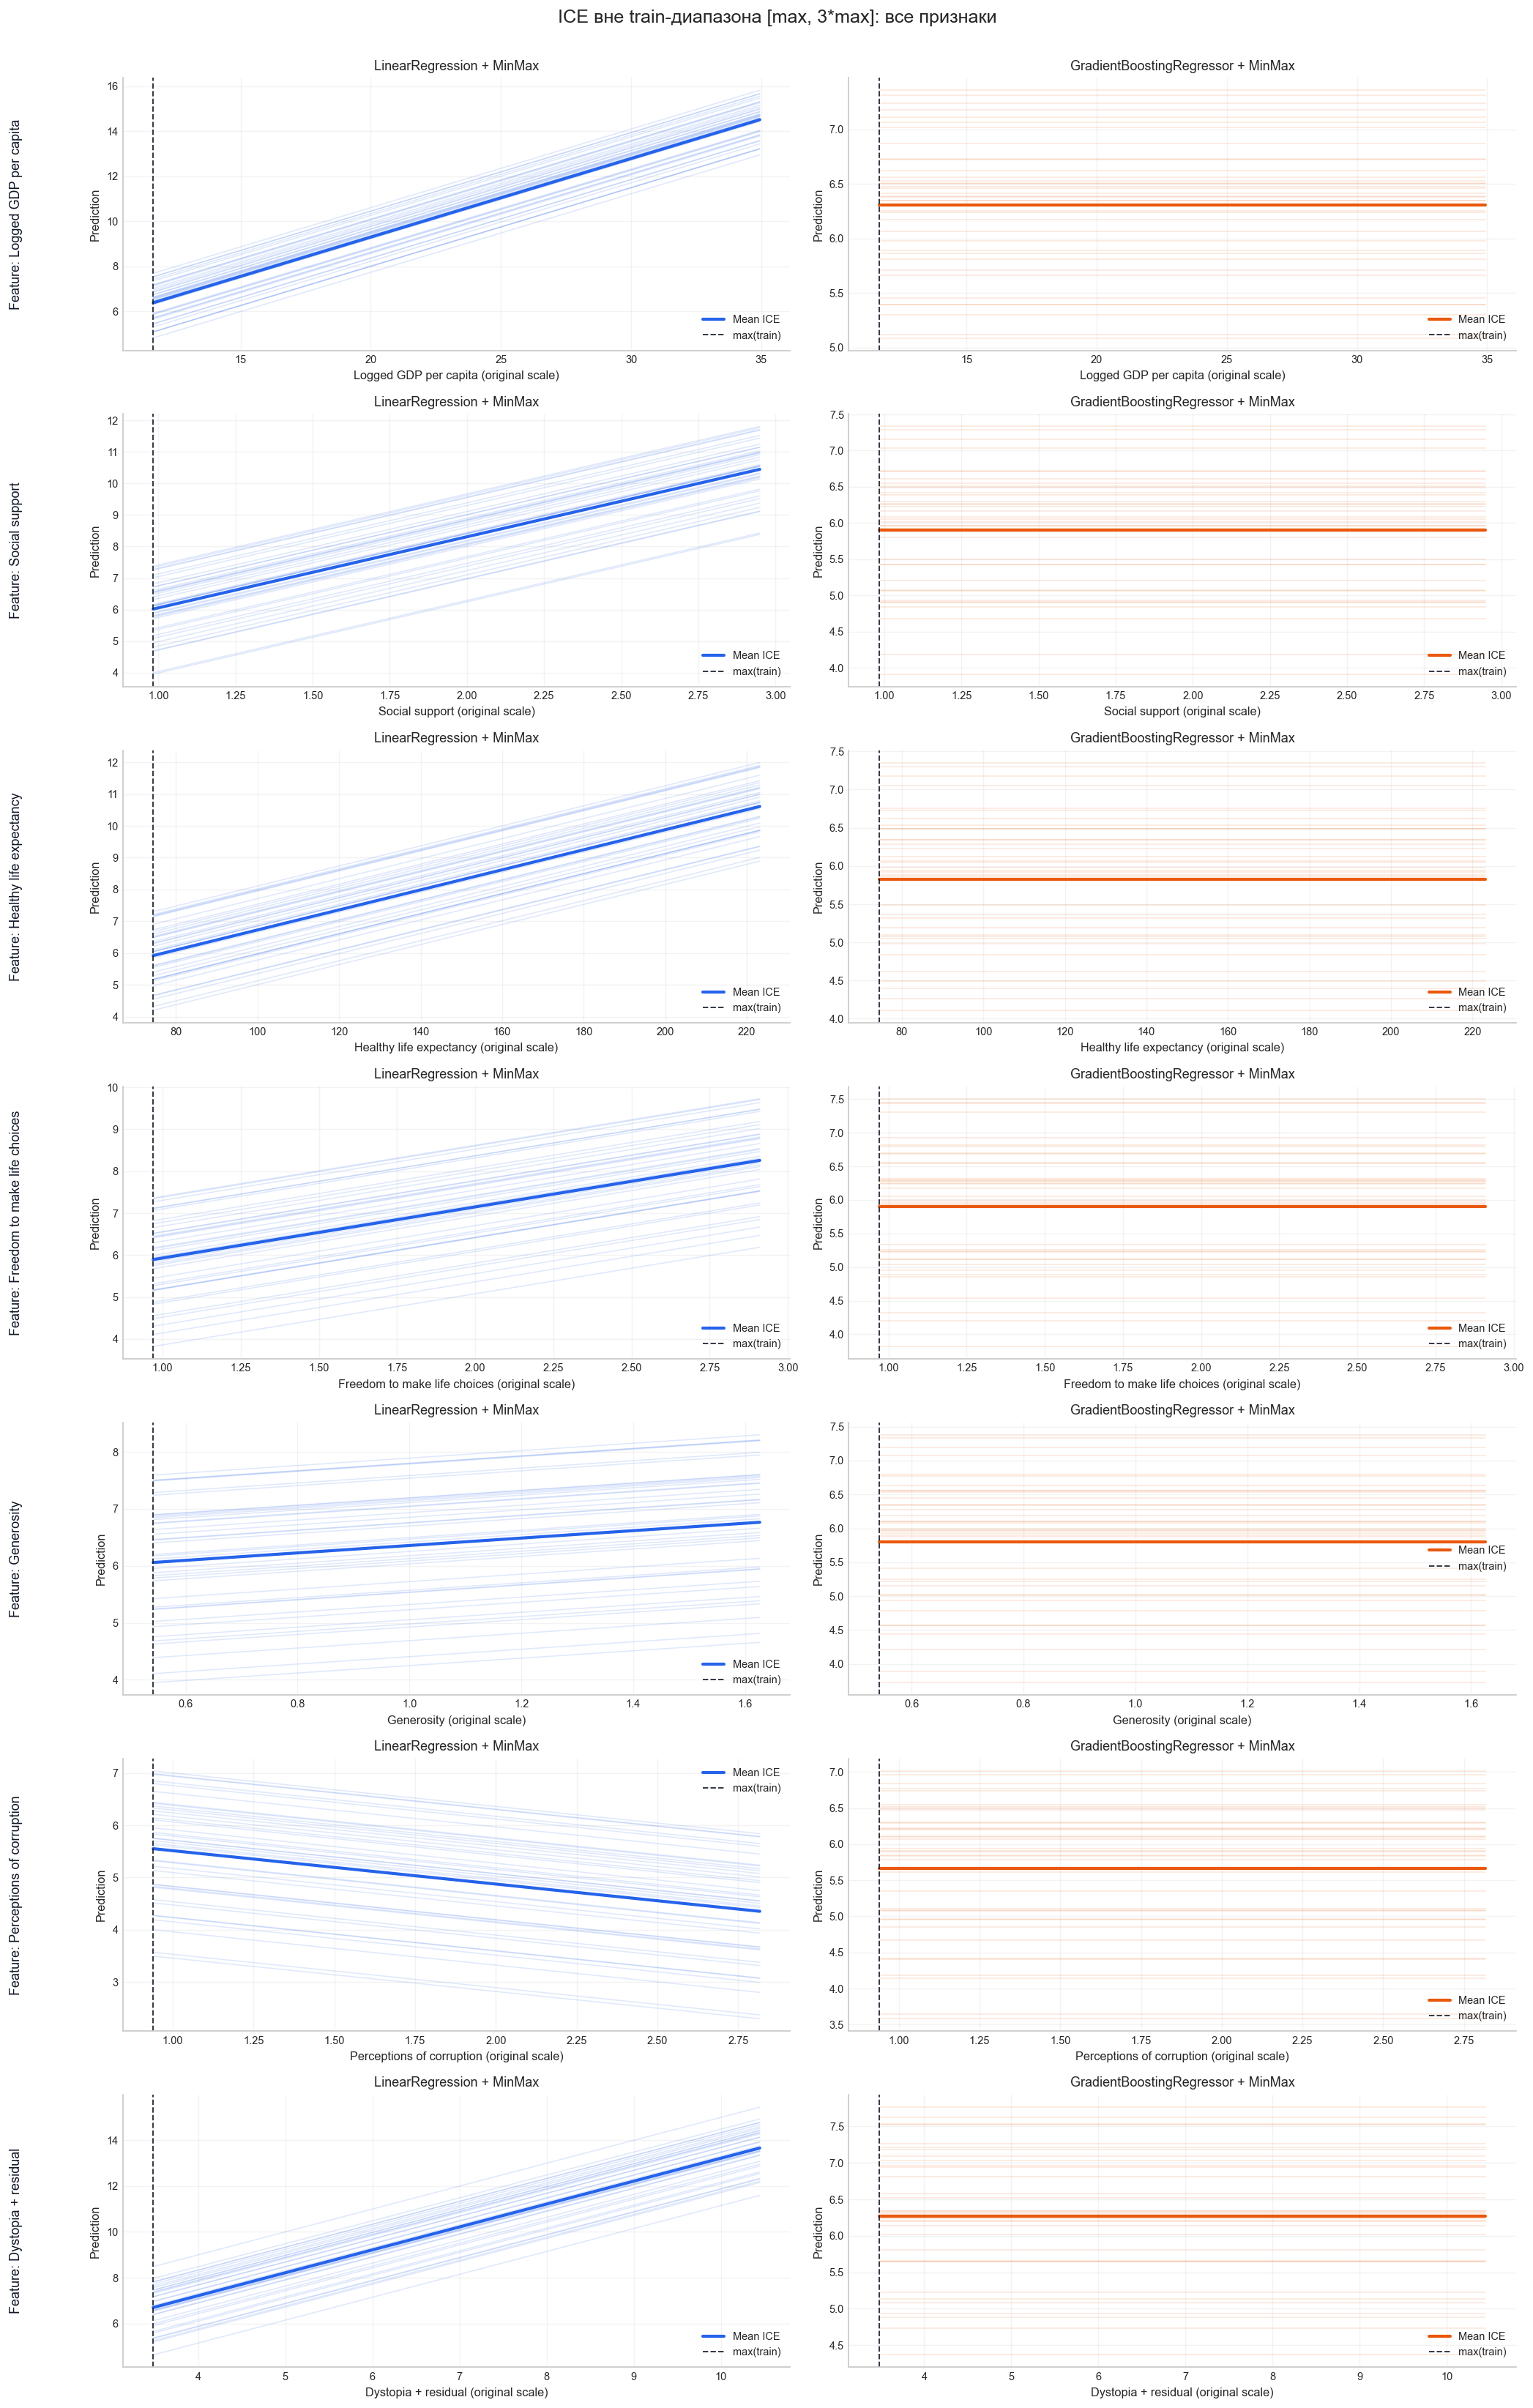

In [15]:
X_train_orig = X_train.to_numpy()
X_test_orig = X_test.to_numpy()


def ice_curves(model, x_test_orig, feat_idx, grid_values, scaler):
    curves = []
    for val in grid_values:
        x_mod = x_test_orig.copy()
        x_mod[:, feat_idx] = val
        x_mod_scaled = scaler.transform(x_mod)
        y_pred = model.predict(x_mod_scaled)
        curves.append(y_pred)
    return np.stack(curves, axis=1)


# NOTE: стиль настроил ГПТ
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    7, 2, figsize=(16, 3.6 * 7), sharex=False, sharey=False, dpi=130
)

for feat_idx in range(7):
    f_max = X_train_orig[:, feat_idx].max()
    grid_orig = np.linspace(f_max, 3.0 * f_max, 20)

    ice_lr = ice_curves(lr_minmax, X_test_orig, feat_idx, grid_orig, sc_minmax)
    ice_gb = ice_curves(gb_minmax, X_test_orig, feat_idx, grid_orig, sc_minmax)

    # NOTE: дальше работали мы с ГПТ (графики -- блевотня)
    row_cfg = [
        (axes[feat_idx, 0], ice_lr, "LinearRegression + MinMax", "#2563EB"),
        (axes[feat_idx, 1], ice_gb, "GradientBoostingRegressor + MinMax", "#EA580C"),
    ]

    for ax, ice, model_title, color in row_cfg:
        # ICE-линии
        for i in range(ice.shape[0]):
            ax.plot(grid_orig, ice[i], color=color, alpha=0.14, lw=0.9)

        # Средняя кривая для читаемости
        mean_curve = ice.mean(axis=0)
        ax.plot(grid_orig, mean_curve, color=color, lw=2.3, label="Mean ICE")

        # Отмечаем правую границу train-диапазона
        ax.axvline(
            f_max, color="#111827", ls="--", lw=1.1, alpha=0.85, label="max(train)"
        )

        ax.set_title(model_title, fontsize=10, pad=6)
        ax.set_xlabel(f"{feature_names[feat_idx]} (original scale)", fontsize=9)
        ax.set_ylabel("Prediction", fontsize=9)
        ax.tick_params(axis="both", labelsize=8)
        ax.grid(True, alpha=0.23)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(frameon=False, fontsize=8, loc="best")

    # Подпись строки слева
    axes[feat_idx, 0].text(
        -0.16,
        0.5,
        f"Feature: {feature_names[feat_idx]}",
        transform=axes[feat_idx, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=10,
        color="#111827",
    )

fig.suptitle("ICE вне train-диапазона [max, 3*max]: все признаки", fontsize=14, y=1.002)
plt.tight_layout()

**Ваш вывод здесь:**

На линейной моделе очевидно что значение таргет будет линейно зависить от изменения параметра, а на ГБР так как это дерево при переходе через максимум ни как не будет меняться значение так как порог будет пройден в любом случае так как модель не встречала знаяений свыше максимального. 

Так же можно заметить что некоторые признаки в линейной модели либо разпросаны либо скгруперованы, это говорит что модель более зависит от сгруперованных признаков так как эффект не сильно отличается от параметра е параметру.

### **1. 2. PDP**

#### ПО ФАКТУ РЕЩШИЛ В ПРЕДЫДУЩЕМ ЗАДАНИИ


Теперь посмотрим на усредненнуе влияние признака.
### **Задание 5. (0.25 балла)**

- Усредните ICE по обеим моделям, используя PDP из sklearn.
- Сделайте выводы.


In [16]:
# Ваш код здесь

In [17]:
# Ваш код здесь

**Ваш вывод здесь:**

### **1. 3. Accumulated Local Effects (ALE)**

Заключительный из основных графических методов — ALE. Ради практики построим и его.

### **Задание 6. (0.5 балла)**

- Постройте ALE по обеим моделям, используя pyALE. (0.15)
- Подберите размер сетки так, чтобы получить доверительные интервалы. (0.05)
- Проанализируйте полученный график. Каковы получились ДИ? Почему они различны для моделей? (0.3)

> Важно: сетку значений строим в исходных единицах признака, но перед подачей в модель применяем тот же scaler, на котором обучение.

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


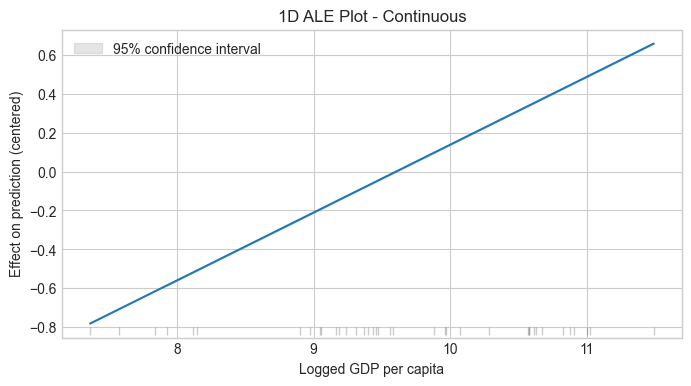

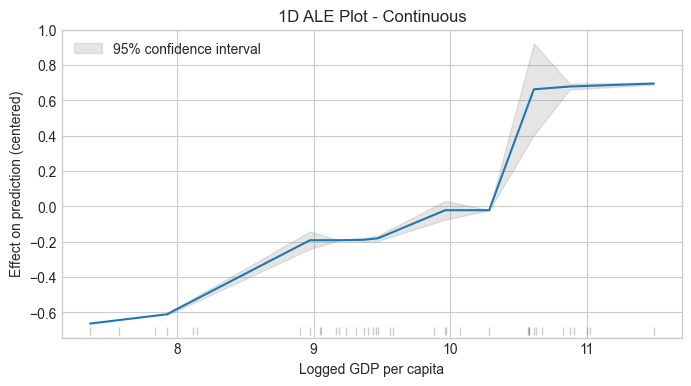

In [18]:
from PyALE import ale
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

grid_size = 10

lr_pipe = make_pipeline(sc_minmax, lr_minmax)
gb_pipe = make_pipeline(sc_minmax, gb_minmax)


feature_name = "Logged GDP per capita"

ale_lr = ale(
    X=X_test.to_pandas(),
    model=lr_pipe,
    feature=[feature_name],
    grid_size=grid_size,
    include_CI=True,
    plot=True,
)

ale_gb = ale(
    X=X_test.to_pandas(),
    model=gb_pipe,
    feature=[feature_name],
    grid_size=grid_size,
    include_CI=True,
    plot=True,
)

**Ваши выводы здесь:**

Очев что линейная модель линейна и отклонение не приведет к наличию интервала, а вот в бустинге влияние в принцепе такое же как и в линейной, но есть резский скачок и как следствие увеличение интервала, так как в этом параметре скроее происходит сравнение и просто большее кол-во листьев попадает в этот диапозон

## **2. Permutation importances**

Практикуем ещё один метод.
### **Задание 7. (0.25 балла)**

- Постройте Permutation importances по обеим моделям, используя sklearn
- Поэкспериментируйте с числом перестановок. (0.05)
- Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов? Зафиксируйте выводы. (0.20)

In [19]:
def plot_permutation_importance_heatmaps(
    df,
    figsize=(14, 6),
):
    # NOTE: CHAT GPT строил графики
    metrics = ["importance_mean", "importance_std"]
    titles = ["Permutation Importance Mean", "Permutation Importance STD"]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, metric, title in zip(axes, metrics, titles):
        heatmap_df = df.pivot(
            values=metric,
            index="feature",
            columns="n_repeats",
        )

        last_col = str(df["n_repeats"].max())
        heatmap_df = heatmap_df.sort(last_col, descending=True)
        heatmap_pd = heatmap_df.to_pandas().set_index("feature")

        im = ax.imshow(
            heatmap_pd.values,
            aspect="auto",
        )

        ax.set_xticks(range(len(heatmap_pd.columns)))
        ax.set_xticklabels(heatmap_pd.columns)

        ax.set_yticks(range(len(heatmap_pd.index)))
        ax.set_yticklabels(heatmap_pd.index)

        for i in range(len(heatmap_pd.index)):
            for j in range(len(heatmap_pd.columns)):
                ax.text(
                    j,
                    i,
                    f"{heatmap_pd.iloc[i, j]:.3f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

        ax.set_title(title)
        ax.set_xlabel("n_repeats")
        ax.set_ylabel("feature")
        fig.colorbar(im, ax=ax, label=metric)

    plt.tight_layout()
    plt.show()


def plot_heat_map_permutation_importance(
    model,
    x,
    y,
    n_repeats_grid=range(2, 10),
):
    res = None

    for n_repeats in n_repeats_grid:
        result = permutation_importance(
            model,
            x,
            y,
            n_repeats=n_repeats,
            random_state=42,
        )

        ans = pl.DataFrame(
            {
                "feature": x.columns,
                "importance_mean": result.importances_mean,
                "importance_std": result.importances_std,
                "n_repeats": [n_repeats] * len(x.columns),
            }
        )

        if res is None:
            res = ans
        else:
            res = pl.concat([res, ans])

    plot_permutation_importance_heatmaps(res)

    return res

In [20]:
plot_heat_map_permutation_importance(lr_pipe, X_test, y_test)
plot_heat_map_permutation_importance(gb_pipe, X_test, y_test)

NameError: name 'permutation_importance' is not defined

**Ваши выводы здесь:** Средняя важность и стд практически  не меняются на не важных признакаха, но вот на более важных происходит увеличение отклонения что понятно, так как больше перестановок и сильное отклонение от результата как следстиве сильный разброс. 

### **Задание 8. (0.5 балла)**

Идея перестановочной важности представляет собой частный случай важности при помощи внесения **возмущений** в признак. Возмущения могут быть разных видов:

- внесение случайного шума;
- зануление признака (удобно для изображений);
- сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели;

В этом задании попробуем построить оценку на основе сдвига к базовому значению траектории. Примем за базовое значение медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:

$$x_j^{(\beta)}=(1-\beta)x_j+\beta b_j$$

где $b_j$ – медиана признака. Важность будем оценивать как изменение MSE по тест-данным.

1. Реализуйте это возмущение. Как меняются важности при разных $\beta$?
2. Постройте bar-график и сравните ранжирование с **permutation importance**. При сравнении, анализируйте только числовые признаки.


Для регрессии эффект очевиден, поэтому эту окклюзию оценивайте только для бустинга.
**Подсказка:**

1. Выберите базовые значения $x_j$ как **медианы по train** (базовые значения обозначим за $b_j$);
2. На тренировочном наборе данных для каждого признака $j$ замените столбец $x_j$ на $x^{(\beta)}_j=(1-\beta)x_j+\beta b_j$ при разных $\beta$, равных $[0.2, 0.5, 1]$.
3. Посчитайте $\Delta L_j = \text{MSE}(y,\hat y^{(\beta)}_j)-\text{MSE}(y,\hat y)$. Чем больше $\Delta L_j$, тем важнее признак.



In [21]:
def occlusion_importance(
    model,
    x: pl.DataFrame,
    y: pl.DataFrame,
    medians: pl.DataFrame = X_train.select(pl.all().median()),
    beta_grid: np.ndarray = np.array([0.2, 0.5, 1]),
):
    mse_base = mean_squared_error(y, model.predict(x))
    res = None
    for beta in beta_grid:
        for colum in x.columns:
            median_change = x.with_columns(
                ((1 - beta) * pl.col(colum) + medians[colum] * beta).alias(colum)
            )

            y_pred = model.predict(median_change)
            mse = mean_squared_error(y, y_pred)

            ans = pl.DataFrame(
                {
                    "colum change": [colum],
                    "beta": [beta],
                    "mse": mse,
                    "mse base diff": abs(mse_base - mse),
                }
            )

            if res is None:
                res = ans
            else:
                res = pl.concat([res, ans])
    return res


res = occlusion_importance(gb_pipe, X_train, y_train)

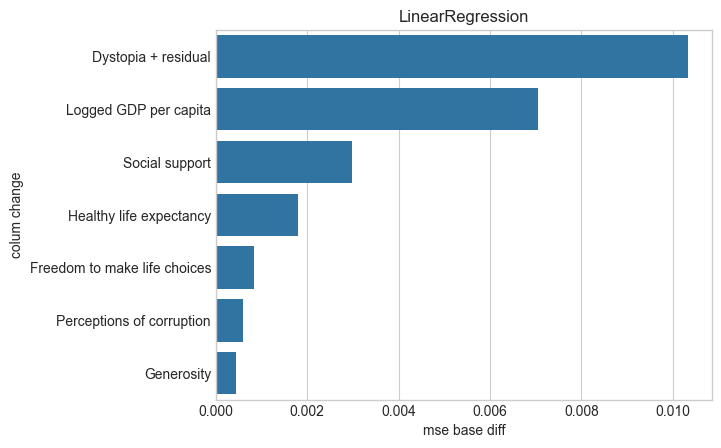

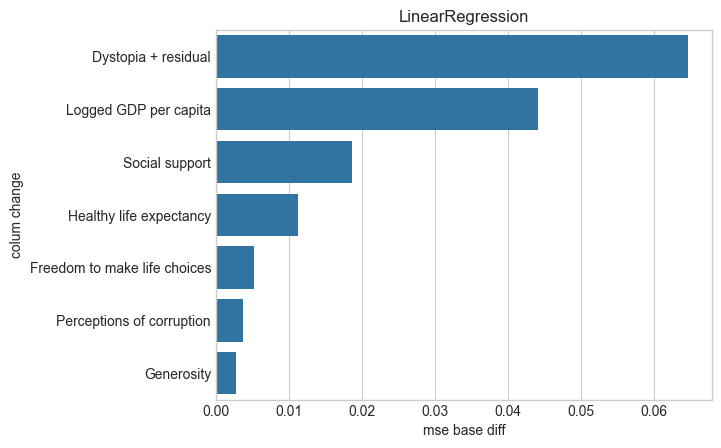

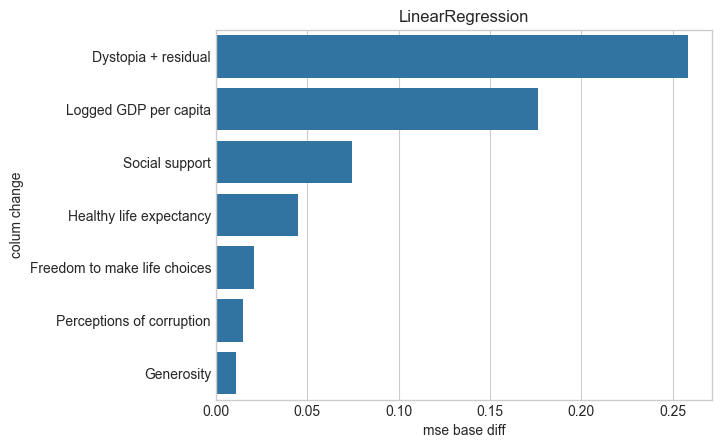

In [22]:
res_lr = occlusion_importance(lr_pipe, X_train, y_train)
for beta in [0.2, 0.5, 1]:
    plt.title("LinearRegression")
    sns.barplot(
        res_lr.filter(pl.col("beta") == beta).sort("mse base diff", descending=True),
        y="colum change",
        x="mse base diff",
    )
    plt.show()

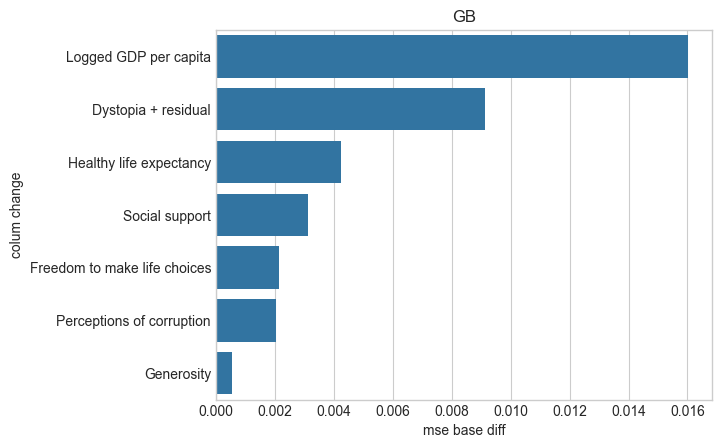

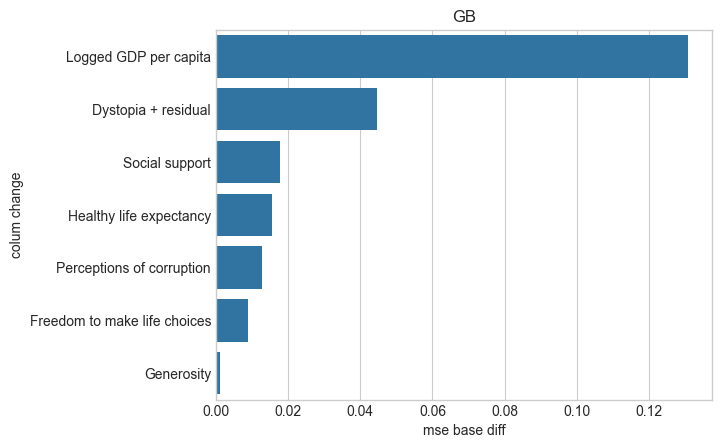

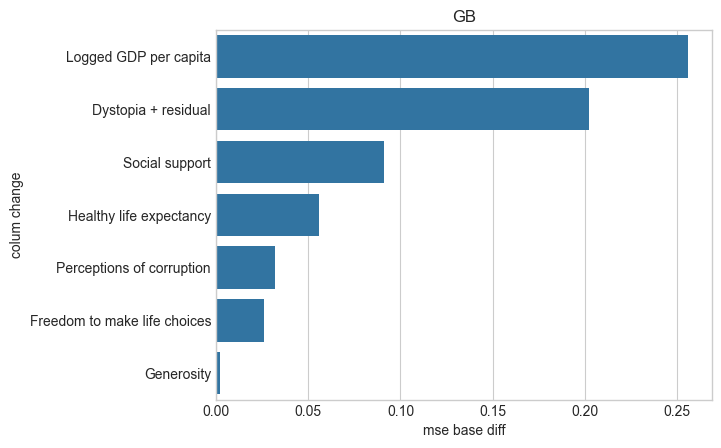

In [23]:
res_gb = occlusion_importance(gb_pipe, X_train, y_train)
for beta in [0.2, 0.5, 1]:
    plt.title("GB")
    sns.barplot(
        res_gb.filter(pl.col("beta") == beta).sort("mse base diff", descending=True),
        y="colum change",
        x="mse base diff",
    )
    plt.show()

**Ваши выводы здесь:** В данном случае, ранжирование поменялось для градиентного бустинга, ВВП и Деспотия поменялись местами.

## **3. SHAP**

Теперь проведем локальный анализ, используя SHAP и LIME. Но для shap также построим глобальные графики.

### **Задание 9. (0.5 баллa)**
- Постройте два глобальных графика, используя SHAP. Как один из них обязательно используйте `force`, как другой — выберите любой из документации. (0.25 балл)
- Проанализируйте важность признаков в обоих алгоритмах.(0.25 балл)

**NB:** Для линейного алгоритма используйте masker=`shap.maskers.Independent(data=X_train_sc)`. Он имитирует отсутствие признака

In [30]:
import shap

shap.initjs()

In [31]:
import shap

lr_minmax = LinearRegression().fit(X_train_sc_minmax, y_train)

explainer = shap.Explainer(lr_minmax, X_train_sc_minmax)
shap_value_lr = explainer(X_test_sc_minmax)

 **Ваш вывод здесь:**

## **Локальное объяснение.**

### **Задание 10. (0.25 балла)**
- Постройте локальный график с SHAP для объекта с индексом 7 на обеих моделях и сделайте выводы.

In [ ]:
# Ваш код здесь

In [ ]:
# Ваш код здесь

**Ваш вывод здесь:**

### **Теория: SHAP + categorical**


SHAP разлагает предсказание модели $f(x)$ на базовый уровень $\phi_0=\mathbb E[f(X)]$ и сумму вкладов признаков:

$$
f(x)=\phi_0+\sum_{j=1}^p \phi_j(x).
$$

Значение $\phi_j(x)$ — это «маржинальный вклад» признака $j$ вблизи точки $x$, усреднённый по всем коалициям признаков. Сумма SHAP по признакам всегда совпадает с предсказанием относительно базовой линии — отсюда удобство интерпретации и сравнимость вкладов.

Однако, вопреки этому удобству, SHAP имеет ограничения при работе с категориальными данными в разных кодировках.


1. OneHotEncoding. В этом случае каждому столбцу присвается свое значение Шепли. Общий вклад здесь — всегда **сумма** dummy-столбцов.
2. В CatBoost используется особый способ категориального разбиения, который (при использовании) фактически создаёт новые признаки для разбиения, отсутствующие в исходном наборе входных признаков. Эти признаки позволяют разбивать целые группы категорий тем или иным образом. Поддержка таких типов деревьев пока не реализована в SHAP, но можно использовать в CatBoost — встроенные [ShapValues](https://catboost.ai/docs/en/concepts/shap-values).
3. При других типах кодировок важно проверять отсутствие утечки.



## **4. LIME**

### **Задание 11. (0.25 балла)**
- Постройте локальный график с LIME для объекта с индексом 7 на обеих моделях и сделайте выводы. Сравните графики с SHAP. Ядро используйте как в семинаре — `kernel_width=np.sqrt(len(feature_names)) * 0.75`

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# Ваш код здесь

In [ ]:
# Ваш код здесь

### **Задание 12. (1 балл)**

Теперь сделаем LIME собственноручно. Ваша реализация должна:

- Принимать на вход точку `x0`
- Вокруг этой точки данных сэмплировать окрестность заданного размера `n`
- На данных из этой окрестности получать прогнозы объясняемой модели (учитывать веса объектов, используя ядро)
- Обучать LIME модель в виде стандартной линейной регрессии
- Возвращать коэффициенты локальной модели


Для своей реализации оцените устойчивость. Как влияет на коэффициенты количество сгенерированных точек? А выбор ядра?

**В реализации вам может помочь библиотека `fatf`**
**Свой LIME тестируйте только для бустинга.**

In [ ]:
# Ваш код здесь — функция

In [ ]:
# Ваш код здесь применение на бустинге

 **Ваш вывод здесь:**

## **Вы проделали огромную работу! Ура!**